# 04 — DGA Fault Classification

When the anomaly detector raises an alert, the next question is **what kind of
fault is this?** Dissolved Gas Analysis (DGA) — measuring concentrations of
fault gases dissolved in the transformer oil — is the standard diagnostic technique.

Different faults produce characteristic gas signatures:
- **Partial discharge** (corona) → mainly H2
- **Low-energy discharge** (sparking) → H2 + C2H2
- **Arcing** (high-energy) → C2H2 dominant
- **Thermal fault <300°C** → CH4 + C2H4
- **Thermal fault >700°C** → C2H4 dominant, some C2H2
- **Normal ageing** → low total dissolved gas

**Standards used:**
- IEC 60599 — interpretation of DGA gas ratios
- Duval Triangle — a graphical fault-typing method using normalized %CH4, %C2H4, %C2H2

**Model:** XGBoost (gradient-boosted trees) with the raw gas concentrations
*plus* engineered features (Duval Triangle coordinates and Rogers Ratios).
XGBoost handles the small, well-separated fault classes well and gives us
SHAP-compatible feature attributions for explainability.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from src.ml_models import DGAFaultClassifier, compute_duval_coordinates
from src.visualization import setup_style, plot_classification_confidence, plot_feature_importance
setup_style()

dga = pd.read_csv('../data/dga_training_set.csv')
print(f"Loaded {len(dga)} labeled DGA samples")
print("Class distribution:")
print(dga.fault_type.value_counts().sort_index().rename(
    {0: "Normal", 1: "PD", 2: "Low-E disch", 3: "Arcing", 4: "Thermal<300", 5: "Thermal>700"}
))

Loaded 1998 labeled DGA samples
Class distribution:
fault_type
Normal         333
PD             333
Low-E disch    333
Arcing         333
Thermal<300    333
Thermal>700    333
Name: count, dtype: int64


## Compute Duval Triangle coordinates

Duval coordinates are the percentage breakdown of CH4, C2H4, C2H2 in the *fault-gas* total:


In [2]:
dga_with_features = compute_duval_coordinates(dga)
dga_with_features[["ch4_ppm", "c2h4_ppm", "c2h2_ppm",
                    "duval_ch4_pct", "duval_c2h4_pct", "duval_c2h2_pct"]].head()

,ch4_ppm,c2h4_ppm,c2h2_ppm,duval_ch4_pct,duval_c2h4_pct,duval_c2h2_pct
0,23.872133,17.120615,0.722176,57.226840,41.041943,1.731217
1,26.872098,27.935026,1.735695,47.525218,49.405081,3.069701
2,23.245089,19.263113,0.905598,53.543087,44.370945,2.085969
3,34.013013,18.682436,0.670832,63.735026,35.007941,1.257033
4,154.420164,217.551948,179.139199,28.019778,39.475137,32.505085


## Train/test split and fit XGBoost

In [3]:
X_train, X_test = train_test_split(dga, test_size=0.2, random_state=42,
                                    stratify=dga.fault_type)

clf = DGAFaultClassifier(n_estimators=200, max_depth=5)
clf.fit(X_train)

preds = clf.predict(X_test)
print("Test set performance:")
print(classification_report(X_test.fault_type, preds, target_names=clf.CLASS_NAMES))

Test set performance:
                      precision    recall  f1-score   support

       Normal ageing       1.00      1.00      1.00        66
   Partial discharge       1.00      1.00      1.00        66
Low-energy discharge       1.00      1.00      1.00        67
              Arcing       1.00      1.00      1.00        67
 Thermal fault <300C       1.00      1.00      1.00        67
 Thermal fault >700C       1.00      1.00      1.00        67

            accuracy                           1.00       400
           macro avg       1.00      1.00      1.00       400
        weighted avg       1.00      1.00      1.00       400



## Confusion matrix

In [4]:
cm = confusion_matrix(X_test.fault_type, preds)
print(pd.DataFrame(cm, index=clf.CLASS_NAMES, columns=clf.CLASS_NAMES).to_string())

                      Normal ageing  Partial discharge  Low-energy discharge  Arcing  Thermal fault <300C  Thermal fault >700C
Normal ageing                    66                  0                     0       0                    0                    0
Partial discharge                 0                 66                     0       0                    0                    0
Low-energy discharge              0                  0                    67       0                    0                    0
Arcing                            0                  0                     0      67                    0                    0
Thermal fault <300C               0                  0                     0       0                   67                    0
Thermal fault >700C               0                  0                     0       0                    0                   67


## Feature importance

Which features does XGBoost find most informative? This gives engineers transparency into *why* the model predicts what it does.


            feature  importance
9    duval_c2h2_pct    0.268081
1           ch4_ppm    0.165678
3          c2h4_ppm    0.146872
11     ratio_ch4_h2    0.139878
2          c2h2_ppm    0.123729
0            h2_ppm    0.065995
10  ratio_c2h2_c2h4    0.056472
7     duval_ch4_pct    0.011896
8    duval_c2h4_pct    0.011428
12  ratio_c2h4_c2h6    0.003871
4          c2h6_ppm    0.003568
6           co2_ppm    0.001624
5            co_ppm    0.000909


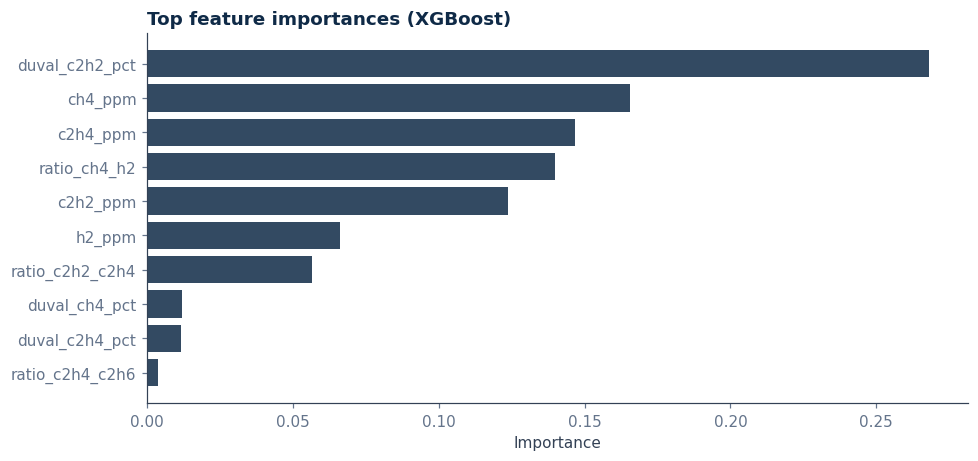

In [5]:
importance = clf.feature_importance()
print(importance)
fig = plot_feature_importance(importance, top_n=10)
plt.show()

## Example: classify a sample with high CH4 + C2H4 (thermal fault signature)

Predicted fault: Thermal fault <300C
Confidence: 99.9%

All class probabilities:
  Normal ageing              0.000  
  Partial discharge          0.000  
  Low-energy discharge       0.000  
  Arcing                     0.000  
  Thermal fault <300C        0.999  #######################################
  Thermal fault >700C        0.000  


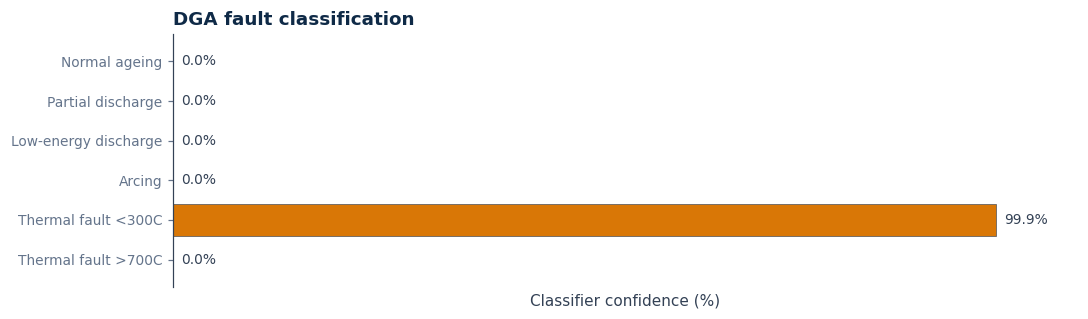

In [6]:
new_sample = pd.DataFrame([{
    "h2_ppm": 45,
    "ch4_ppm": 195,
    "c2h2_ppm": 1,
    "c2h4_ppm": 215,
    "c2h6_ppm": 85,
    "co_ppm": 700,
    "co2_ppm": 4500,
}])

probs = clf.predict_proba(new_sample)[0]
pred = clf.predict(new_sample)[0]

print(f"Predicted fault: {clf.CLASS_NAMES[pred]}")
print(f"Confidence: {probs[pred]:.1%}\n")
print("All class probabilities:")
for name, p in zip(clf.CLASS_NAMES, probs):
    bar = "#" * int(p * 40)
    print(f"  {name:25s}  {p:.3f}  {bar}")

fig = plot_classification_confidence(clf.CLASS_NAMES, probs)
plt.show()

## Next step

Notebook **05_rul_forecasting** is the final ML layer: forecasting how many days
remain before the asset hits a maintenance threshold. This drives the
condition-based maintenance schedule on the operator dashboard.
